<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unveiling the Android App Market: Analyzing Google Play Store Data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from google.colab import files
uploaded = files.upload()
apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')
print("Apps shape:   ", apps.shape)
print("Reviews shape:", reviews.shape)
apps.head()

Saving apps.csv to apps (1).csv
Saving user_reviews.csv to user_reviews.csv
Apps shape:    (9659, 14)
Reviews shape: (64295, 5)


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=apps)

https://docs.google.com/spreadsheets/d/1-p0DM_gHn6yywaeu5h1N6qvm-MEVfiIF61d84Kqv-qU/edit#gid=0


In [6]:
print(apps.dtypes)
print("\nMissing values:\n", apps.isnull().sum())
print("\nMissing Values :\n", reviews.isnull().sum())

Unnamed: 0          int64
App                object
Category           object
Rating            float64
Reviews             int64
Size              float64
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Missing values:
 Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Missing Values :
 App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


**App Dataset Cleaning**

In [7]:
apps.drop(columns=['Unnamed: 0'], inplace=True)
apps.drop_duplicates(subset='App', inplace=True)
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')
apps['Price'] = apps['Price'].astype(str).str.replace('$', '', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')
apps.dropna(subset=['Rating'], inplace=True)
print("Clean shape:", apps.shape)
apps[['App', 'Installs', 'Price', 'Rating']].head()

Clean shape: (8196, 13)


,App,Installs,Price,Rating
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000,0.0,4.1
1,Coloring book moana,500000,0.0,3.9
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000,0.0,4.7
3,Sketch - Draw & Paint,50000000,0.0,4.5
4,Pixel Draw - Number Art Coloring Book,100000,0.0,4.3


**App Distribution by Category**

/tmp/ipykernel_4042/2364680306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


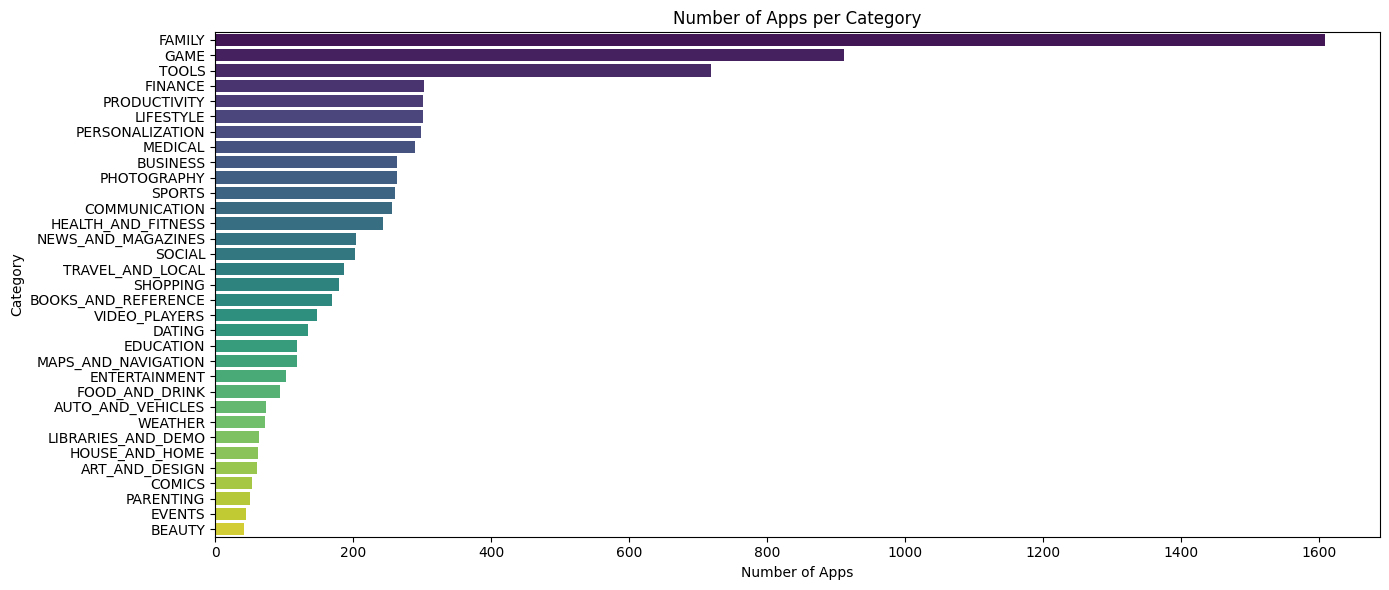

In [9]:
plt.figure(figsize=(14, 6))
category_counts = apps['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Number of Apps per Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Rating Distribution**

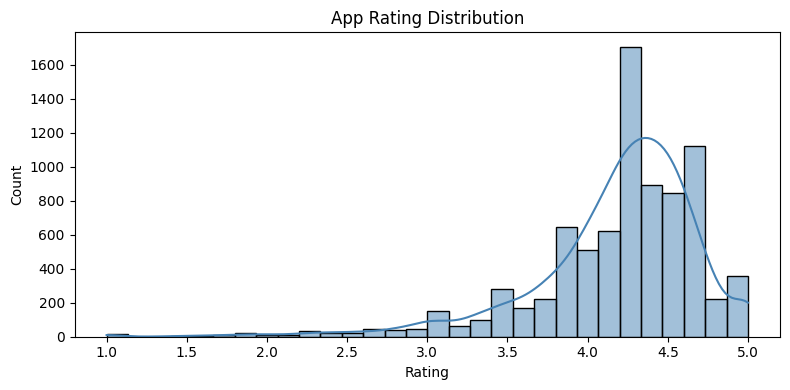

Average Rating: 4.17


In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(apps['Rating'], bins=30, kde=True, color='steelblue')
plt.title('App Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Average Rating:", round(apps['Rating'].mean(), 2))

**Top 10 Categories by Average Rating**

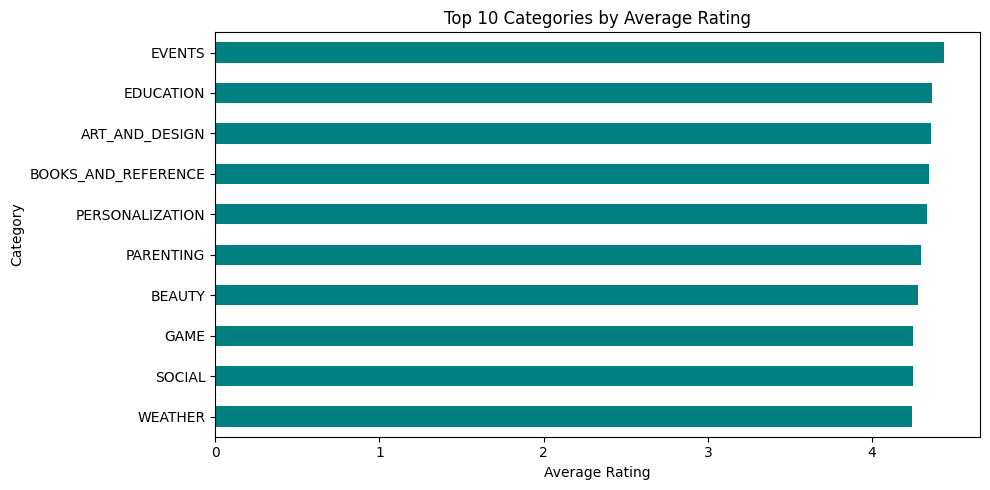

In [10]:
avg_rating = apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
avg_rating.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

**Most Installed Categories**

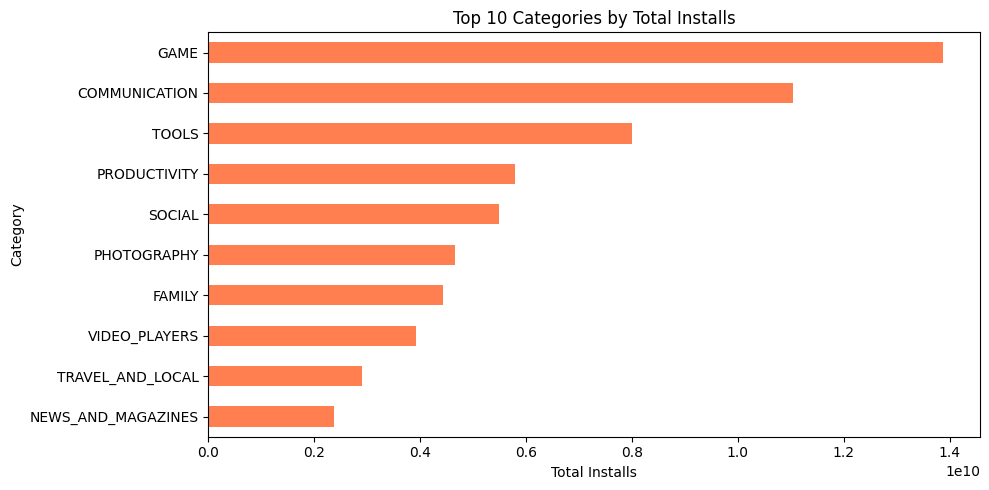

In [11]:
installs_by_cat = apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
installs_by_cat.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Categories by Total Installs')
plt.xlabel('Total Installs')
plt.tight_layout()
plt.show()

**Free vs Paid Apps**

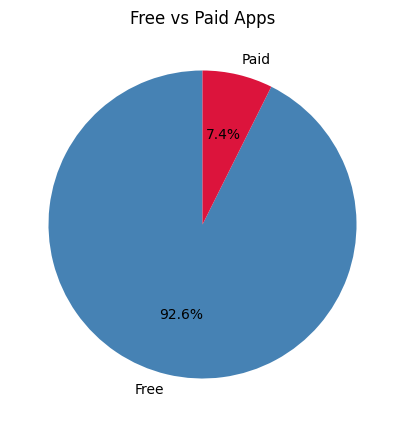

Type
Free    7592
Paid     604
Name: count, dtype: int64


In [12]:
type_counts = apps['Type'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',colors=['steelblue', 'crimson'], startangle=90)
plt.title('Free vs Paid Apps')
plt.show()
print(type_counts)

**Price Distribution of Paid Apps**

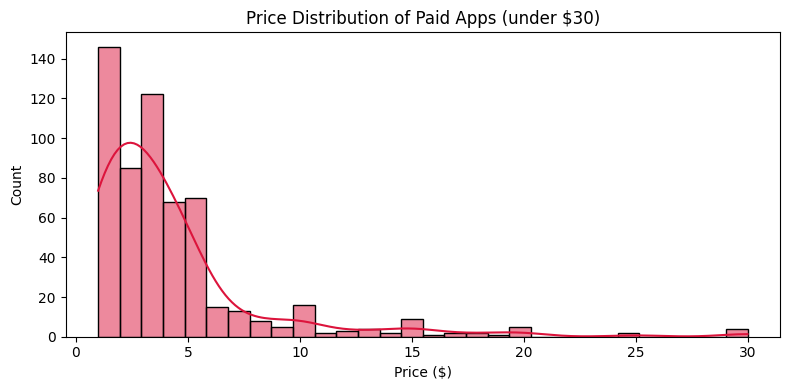

Average paid app price: $ 14.08


In [13]:
paid_apps = apps[apps['Type'] == 'Paid']
plt.figure(figsize=(8, 4))
sns.histplot(paid_apps[paid_apps['Price'] < 30]['Price'], bins=30, color='crimson', kde=True)
plt.title('Price Distribution of Paid Apps (under $30)')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()
print("Average paid app price: $", round(paid_apps['Price'].mean(), 2))

**App Size vs Rating**

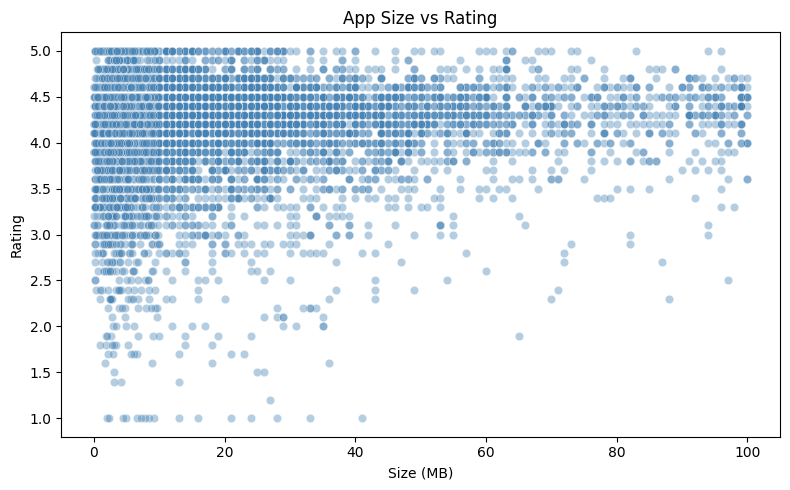

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=apps, x='Size', y='Rating', alpha=0.4, color='steelblue')
plt.title('App Size vs Rating')
plt.xlabel('Size (MB)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

**Reviews vs Installs**

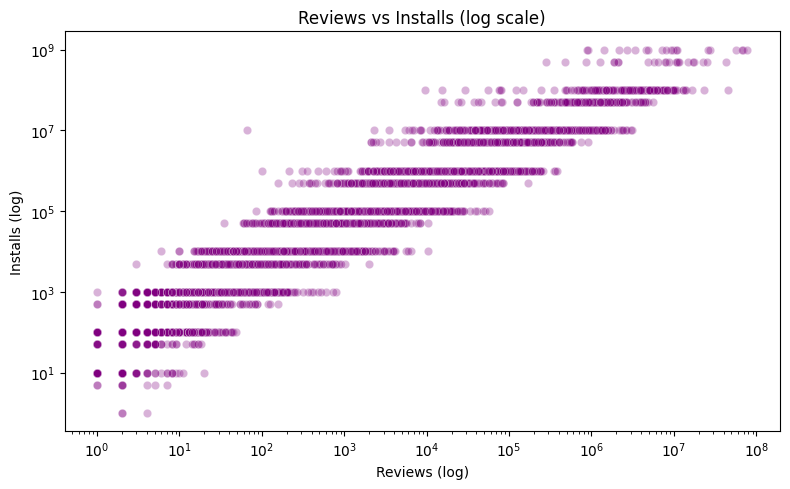

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=apps, x='Reviews', y='Installs', alpha=0.3, color='purple')
plt.xscale('log')
plt.yscale('log')
plt.title('Reviews vs Installs (log scale)')
plt.xlabel('Reviews (log)')
plt.ylabel('Installs (log)')
plt.tight_layout()
plt.show()

**Content Rating Breakdown**

/tmp/ipykernel_4042/121466881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=content_counts.values, y=content_counts.index, palette='Set2')


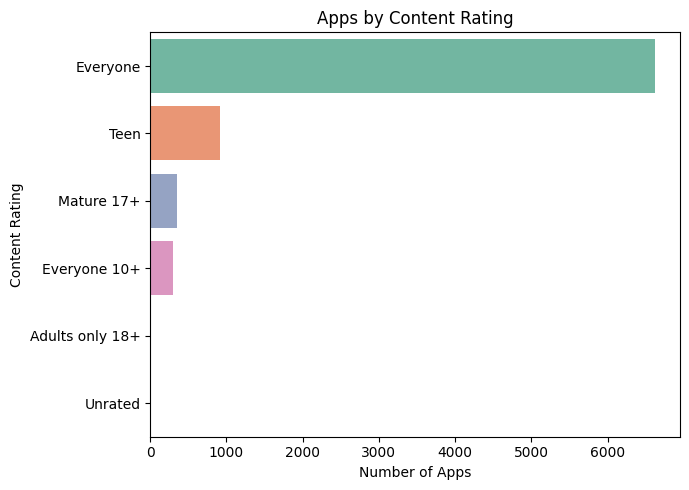

In [16]:
content_counts = apps['Content Rating'].value_counts()
plt.figure(figsize=(7, 5))
sns.barplot(x=content_counts.values, y=content_counts.index, palette='Set2')
plt.title('Apps by Content Rating')
plt.xlabel('Number of Apps')
plt.tight_layout()
plt.show()

**Load & Explore Reviews**

In [17]:
print("Reviews shape:", reviews.shape)
print("\nMissing values:\n", reviews.isnull().sum())
print("\nSentiment distribution:\n", reviews['Sentiment'].value_counts())
reviews.head()

Reviews shape: (64295, 5)

Missing values:
 App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

Sentiment distribution:
 Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


**Sentiment Distribution (Pie Chart)**

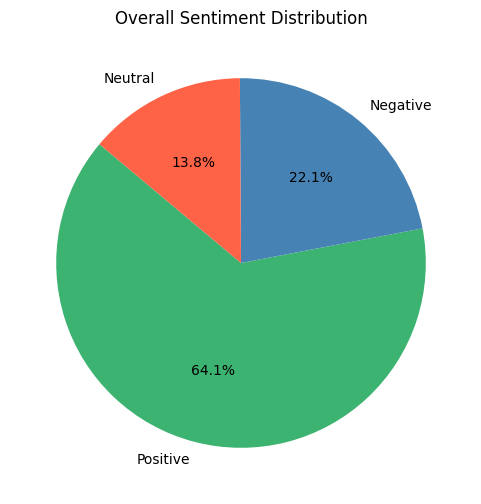

In [18]:
sentiment_counts = reviews['Sentiment'].value_counts().dropna()
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',colors=['mediumseagreen', 'steelblue', 'tomato'], startangle=140)
plt.title('Overall Sentiment Distribution')
plt.show()

**Sentiment Polarity Distribution**

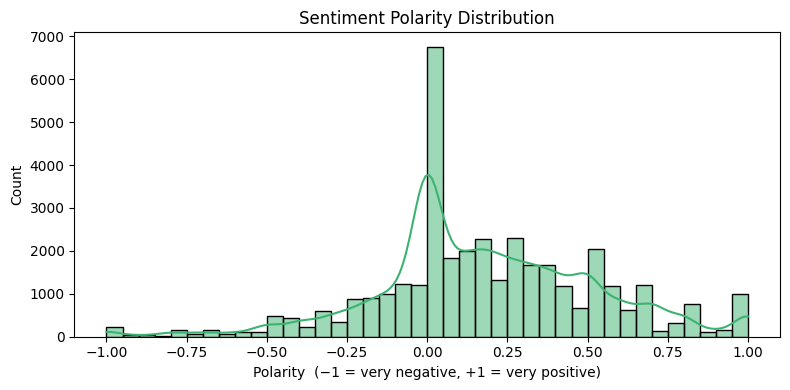

Average Polarity: 0.182


In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(reviews['Sentiment_Polarity'].dropna(), bins=40, kde=True, color='mediumseagreen')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity  (−1 = very negative, +1 = very positive)')
plt.tight_layout()
plt.show()
print("Average Polarity:", round(reviews['Sentiment_Polarity'].mean(), 3))

**Merge Apps + Reviews**

In [20]:
merged = apps.merge(reviews, on='App', how='inner')
print("Merged shape:", merged.shape)
merged[['App', 'Category', 'Rating', 'Sentiment', 'Sentiment_Polarity']].head()

Merged shape: (61556, 17)


,App,Category,Rating,Sentiment,Sentiment_Polarity
0,Coloring book moana,ART_AND_DESIGN,3.9,Negative,-0.250
1,Coloring book moana,ART_AND_DESIGN,3.9,Negative,-0.725
2,Coloring book moana,ART_AND_DESIGN,3.9,Neutral,0.000
3,Coloring book moana,ART_AND_DESIGN,3.9,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,Positive,0.500


**Sentiment Polarity by Category (Top 10)**

/tmp/ipykernel_4042/2234018251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered, x='Category', y='Sentiment_Polarity', palette='Set3')


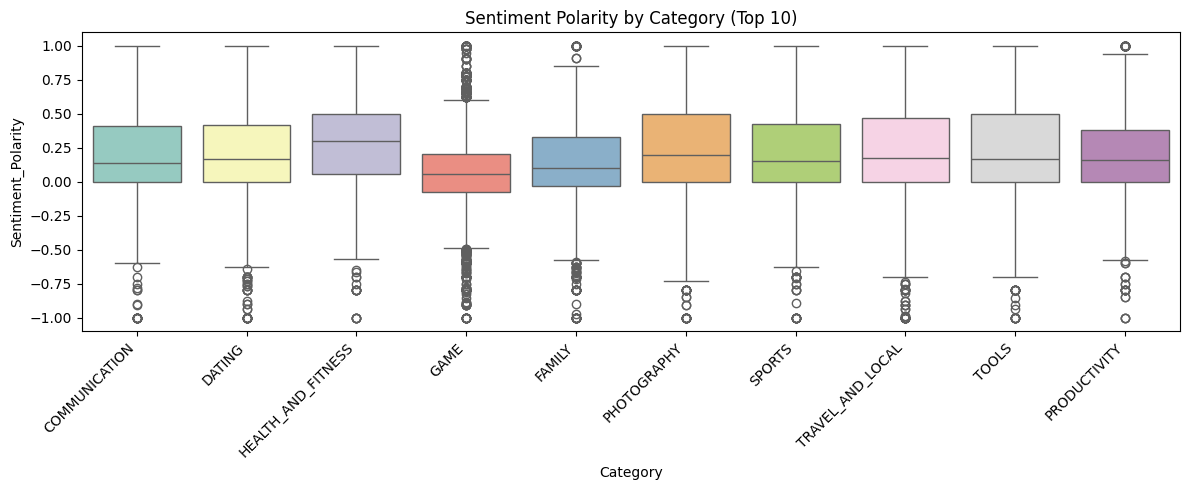

In [21]:
top_cats = merged['Category'].value_counts().head(10).index
filtered = merged[merged['Category'].isin(top_cats)]
plt.figure(figsize=(12, 5))
sns.boxplot(data=filtered, x='Category', y='Sentiment_Polarity', palette='Set3')
plt.xticks(rotation=45, ha='right')
plt.title('Sentiment Polarity by Category (Top 10)')
plt.tight_layout()
plt.show()

**Rating vs Sentiment Polarity**

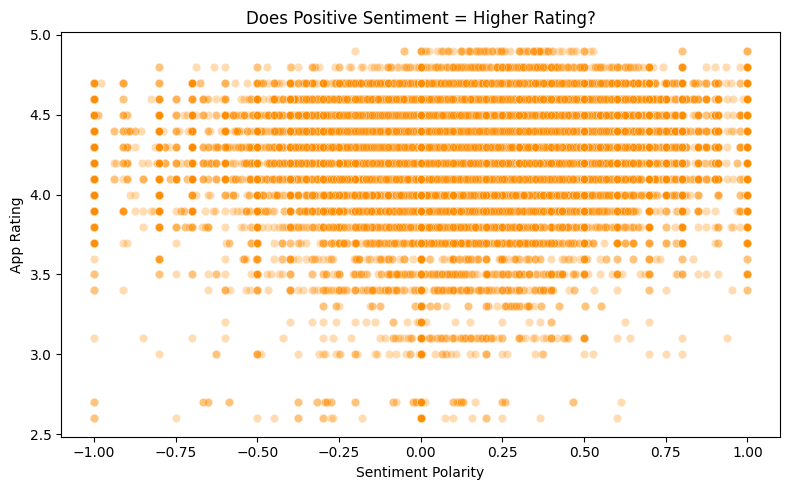

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=merged, x='Sentiment_Polarity', y='Rating', alpha=0.3, color='darkorange')
plt.title('Does Positive Sentiment = Higher Rating?')
plt.xlabel('Sentiment Polarity')
plt.ylabel('App Rating')
plt.tight_layout()
plt.show()

**Word Cloud of Positive Reviews**

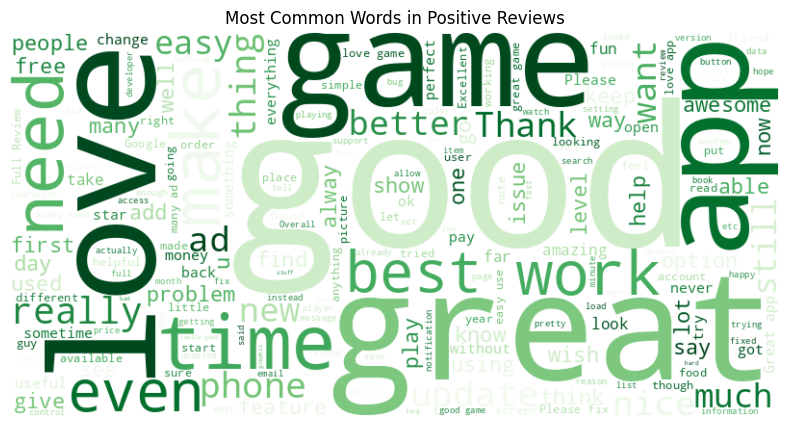

In [24]:
positive_text = ' '.join(reviews[reviews['Sentiment'] == 'Positive']['Translated_Review'].dropna())
wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

**Word Cloud of Negative Reviews**

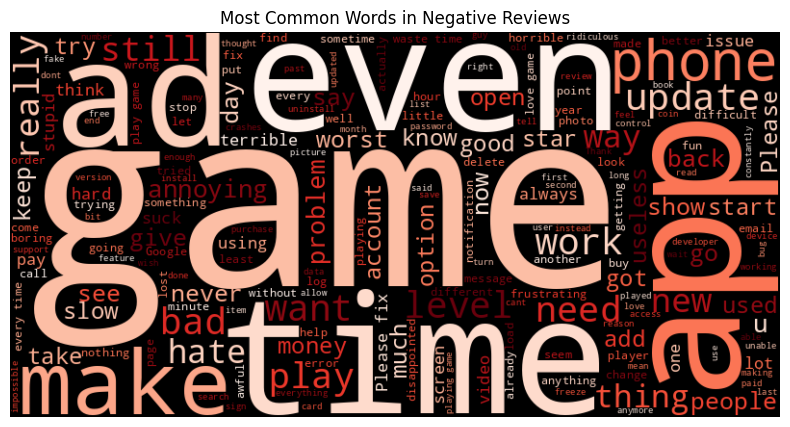

In [25]:
negative_text = ' '.join(reviews[reviews['Sentiment'] == 'Negative']['Translated_Review'].dropna())

wc = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

**Top 10 Apps by Installs**

In [ ]:
top10 = apps.nlargest(10, 'Installs')[['App', 'Category', 'Installs', 'Rating']]
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='Installs', y='App', palette='Blues_r')
plt.title('Top 10 Most Installed Apps')
plt.xlabel('Total Installs')
plt.tight_layout()
plt.show()

**Final Summary Stats**

In [28]:
print("=== SUMMARY ===")
print(f"Total Apps:         {len(apps)}")
print(f"Total Categories:   {apps['Category'].nunique()}")
print(f"Free Apps:          {(apps['Type'] == 'Free').sum()}")
print(f"Paid Apps:          {(apps['Type'] == 'Paid').sum()}")
print(f"Average Rating:     {round(apps['Rating'].mean(), 2)}")
print(f"Avg Paid Price:     ${round(apps[apps['Type']=='Paid']['Price'].mean(), 2)}")
print(f"Total Reviews:      {len(reviews)}")
print(f"Positive Reviews:   {(reviews['Sentiment'] == 'Positive').sum()}")
print(f"Negative Reviews:   {(reviews['Sentiment'] == 'Negative').sum()}")
print(f"Avg Polarity:       {round(reviews['Sentiment_Polarity'].mean(), 3)}")

=== SUMMARY ===
Total Apps:         8196
Total Categories:   33
Free Apps:          7592
Paid Apps:          604
Average Rating:     4.17
Avg Paid Price:     $14.08
Total Reviews:      64295
Positive Reviews:   23998
Negative Reviews:   8271
Avg Polarity:       0.182
